In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")



df_loans = pd.read_csv("funded_loans.csv")
df_cost  = pd.read_csv("cost_allocation.csv")
df_gl    = pd.read_csv("general_ledger.csv")
df_lock  = pd.read_csv("lock_pipeline.csv")

# ── Convert date columns ──
df_loans["funded_month"] = pd.to_datetime(df_loans["funded_month"])
df_cost["cost_month"]    = pd.to_datetime(df_cost["cost_month"])
df_gl["gl_month"]        = pd.to_datetime(df_gl["gl_month"])
df_lock["lock_month"]    = pd.to_datetime(df_lock["lock_month"])

print("funded_loans  :", df_loans.shape,  " columns:", df_loans.columns.tolist())
print("cost_allocation:", df_cost.shape,  " columns:", df_cost.columns.tolist())
print("general_ledger :", df_gl.shape,    " columns:", df_gl.columns.tolist())
print("lock_pipeline  :", df_lock.shape,  " columns:", df_lock.columns.tolist())

funded_loans  : (10000, 8)  columns: ['loan_id', 'channel', 'product', 'funded_amount', 'funded_month', 'margin_bps', 'interest_rate', 'state']
cost_allocation: (36, 5)  columns: ['cost_center', 'cost_month', 'fixed_cost', 'variable_cost', 'headcount']
general_ledger : (60, 4)  columns: ['gl_account', 'gl_month', 'amount', 'category']
lock_pipeline  : (12000, 5)  columns: ['lock_id', 'channel', 'lock_month', 'locked_amount', 'funded_flag']


In [6]:
# ── Funded Loans: monthly aggregates ──
monthly = df_loans.groupby("funded_month").agg(
    total_volume  = ("funded_amount", "sum"),
    avg_margin    = ("margin_bps",    "mean"),
    avg_rate      = ("interest_rate", "mean"),
    loan_count    = ("loan_id",       "count"),
).reset_index()

monthly["gross_revenue"] = monthly["total_volume"] * monthly["avg_margin"] / 10_000

# ── Cost: monthly total ──
cost_monthly = df_cost.groupby("cost_month").agg(
    fixed_cost    = ("fixed_cost",    "sum"),
    variable_cost = ("variable_cost", "sum"),
    headcount     = ("headcount",     "sum"),
).reset_index()
cost_monthly["total_cost"] = cost_monthly["fixed_cost"] + cost_monthly["variable_cost"]

# ── Merge revenue + cost ──
monthly = monthly.merge(
    cost_monthly[["cost_month","total_cost","headcount"]],
    left_on="funded_month", right_on="cost_month", how="left"
).drop(columns="cost_month")

monthly["net_profit"]    = monthly["gross_revenue"] - monthly["total_cost"]
monthly["net_margin_pct"]= monthly["net_profit"]    / monthly["gross_revenue"]
monthly["cost_per_loan"] = monthly["total_cost"]    / monthly["loan_count"]
monthly["rev_per_loan"]  = monthly["gross_revenue"] / monthly["loan_count"]

# ── Lock pipeline: pull-through rate ──
pt = df_lock.groupby("lock_month").agg(
    total_locks    = ("lock_id",       "count"),
    funded_locks   = ("funded_flag",   "sum"),
    total_locked   = ("locked_amount", "sum"),
    funded_amount  = ("locked_amount", lambda x: x[df_lock.loc[x.index,"funded_flag"]==1].sum()),
).reset_index()
pt["pull_through_pct"] = pt["funded_locks"] / pt["total_locks"]

print("\n── Monthly P&L Summary ─────────────────────────────────────────────")
print(monthly[["funded_month","total_volume","gross_revenue",
               "total_cost","net_profit","net_margin_pct"]].to_string(index=False))

print(f"\n── FY 2024 Totals ──────────────────────────────────────────────────")
print(f"  Total Volume   : ${monthly['total_volume'].sum():>15,.0f}")
print(f"  Gross Revenue  : ${monthly['gross_revenue'].sum():>15,.0f}")
print(f"  Total Costs    : ${monthly['total_cost'].sum():>15,.0f}")
print(f"  Net Profit     : ${monthly['net_profit'].sum():>15,.0f}")
print(f"  Net Margin     :  {monthly['net_profit'].sum()/monthly['gross_revenue'].sum():>14.1%}")
print(f"  Avg Pull-Through: {pt['pull_through_pct'].mean():>13.1%}")


── Monthly P&L Summary ─────────────────────────────────────────────
funded_month  total_volume  gross_revenue  total_cost   net_profit  net_margin_pct
  2024-01-01     541264322   1.706721e+07     1041460 1.602575e+07        0.938979
  2024-02-01     560516868   1.754855e+07     1021875 1.652668e+07        0.941769
  2024-03-01     541944358   1.703831e+07     1018724 1.601958e+07        0.940210
  2024-04-01     553947606   1.740439e+07      793711 1.661068e+07        0.954396
  2024-05-01     549344986   1.730976e+07     1135147 1.617461e+07        0.934422
  2024-06-01     563915347   1.779219e+07     1007612 1.678458e+07        0.943368
  2024-07-01     546635696   1.708356e+07      921160 1.616240e+07        0.946079
  2024-08-01     552892584   1.737894e+07     1073012 1.630593e+07        0.938258
  2024-09-01     583469288   1.836013e+07      851945 1.750818e+07        0.953598
  2024-10-01     552722068   1.737923e+07     1013675 1.636555e+07        0.941673
  2024-11-01     

In [7]:
monthly["month_num"] = range(1, len(monthly) + 1)
x = monthly["month_num"].values
y = monthly["total_volume"].values

coeffs   = np.polyfit(x, y, 1)
m_slope, b_intercept = coeffs
r_sq     = np.corrcoef(x, y)[0, 1] ** 2

monthly["trend_line"] = np.polyval(coeffs, x)

print(f"── Regression Results ──────────────────────────────────────────────")
print(f"  Slope     : ${m_slope:>12,.0f} / month")
print(f"  Intercept : ${b_intercept:>12,.0f}")
print(f"  R²        : {r_sq:.4f}  ({'strong' if r_sq>0.7 else 'moderate' if r_sq>0.4 else 'weak'} fit)")

# ── 6-month forward forecast ──
forecast_nums    = list(range(13, 19))
forecast_volumes = np.polyval(coeffs, forecast_nums)
forecast_dates   = pd.date_range("2025-01-01", periods=6, freq="MS")

avg_margin_fy    = monthly["avg_margin"].mean()
forecast_margins = [round(avg_margin_fy - (i * 0.8), 2) for i in range(6)]
forecast_revenue = [v * mg / 10_000 for v, mg in zip(forecast_volumes, forecast_margins)]

forecast_df = pd.DataFrame({
    "month":          forecast_dates,
    "volume":         [round(v, 0) for v in forecast_volumes],
    "avg_margin_bps": forecast_margins,
    "gross_revenue":  [round(r, 2) for r in forecast_revenue],
    "month_num":      forecast_nums,
})

print(f"\n── 6-Month Forecast (Jan–Jun 2025) ─────────────────────────────────")
print(forecast_df[["month","volume","avg_margin_bps","gross_revenue"]].to_string(index=False))
print(f"\n  Total Forecast Volume  : ${forecast_df['volume'].sum():>15,.0f}")
print(f"  Total Forecast Revenue : ${forecast_df['gross_revenue'].sum():>15,.0f}")

── Regression Results ──────────────────────────────────────────────
  Slope     : $   2,944,845 / month
  Intercept : $ 540,093,443
  R²        : 0.4439  (moderate fit)

── 6-Month Forecast (Jan–Jun 2025) ─────────────────────────────────
     month      volume  avg_margin_bps  gross_revenue
2025-01-01 578376427.0          314.48    18188781.89
2025-02-01 581321272.0          313.68    18234885.67
2025-03-01 584266117.0          312.88    18280518.28
2025-04-01 587210962.0          312.08    18325679.71
2025-05-01 590155807.0          311.28    18370369.96
2025-06-01 593100652.0          310.48    18414589.05

  Total Forecast Volume  : $  3,514,431,237
  Total Forecast Revenue : $    109,814,825


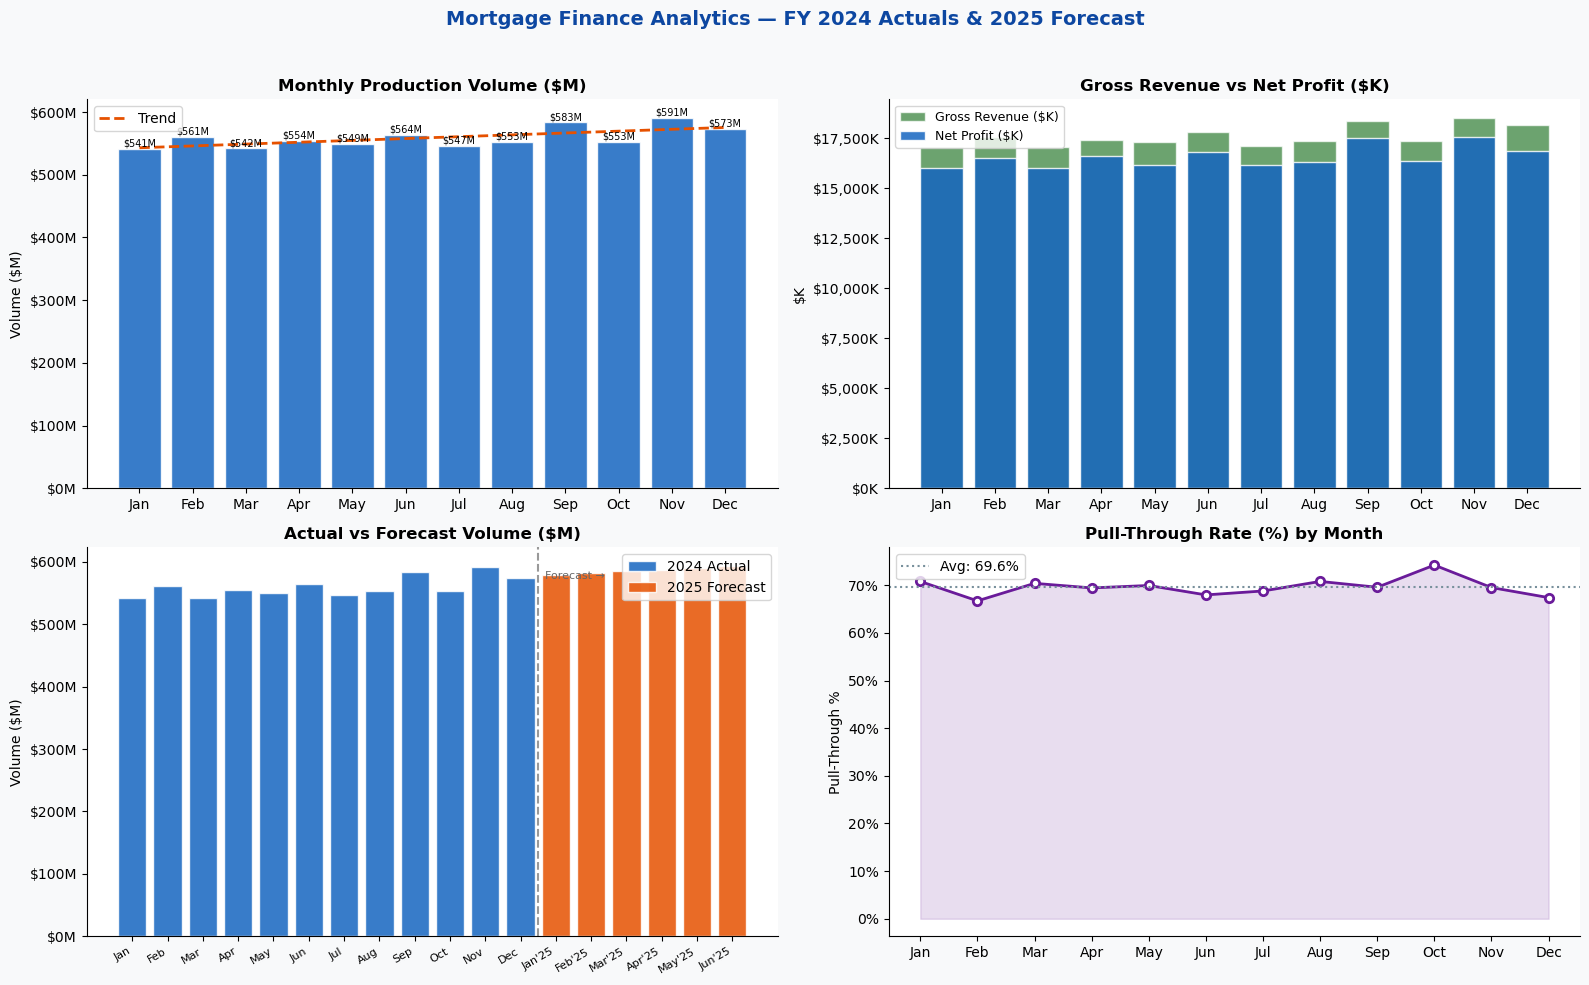

✅ forecast_charts.png saved


In [8]:
BLUE   = "#1565C0"
ORANGE = "#E65100"
GREEN  = "#2E7D32"
GRAY   = "#78909C"
PURPLE = "#6A1B9A"

month_labels = [d.strftime("%b") for d in monthly["funded_month"]]
all_labels   = month_labels + [d.strftime("%b'25") for d in forecast_df["month"]]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle("Mortgage Finance Analytics — FY 2024 Actuals & 2025 Forecast",
             fontsize=14, fontweight="bold", y=0.98, color="#0D47A1")

# Panel 1: Monthly Volume + Trend
ax = axes[0, 0]
bars = ax.bar(month_labels, monthly["total_volume"]/1e6,
              color=BLUE, alpha=0.85, edgecolor="white")
ax.plot(month_labels, monthly["trend_line"]/1e6,
        color=ORANGE, linewidth=2, linestyle="--", label="Trend")
ax.set_title("Monthly Production Volume ($M)", fontweight="bold")
ax.set_ylabel("Volume ($M)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}M"))
ax.legend(); ax.spines[["top","right"]].set_visible(False)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"${bar.get_height():.0f}M", ha="center", va="bottom", fontsize=7)

# Panel 2: Net Profit vs Gross Revenue
ax = axes[0, 1]
x_pos = range(len(month_labels))
ax.bar(x_pos, monthly["gross_revenue"]/1e3, color=GREEN, alpha=0.7,
       label="Gross Revenue ($K)", edgecolor="white")
ax.bar(x_pos, monthly["net_profit"]/1e3, color=BLUE, alpha=0.85,
       label="Net Profit ($K)", edgecolor="white")
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_title("Gross Revenue vs Net Profit ($K)", fontweight="bold")
ax.set_ylabel("$K")
ax.set_xticks(x_pos); ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}K"))
ax.legend(fontsize=9); ax.spines[["top","right"]].set_visible(False)

# Panel 3: Actual vs Forecast Volume
ax = axes[1, 0]
ax.bar(range(12), monthly["total_volume"]/1e6,
       color=BLUE, alpha=0.85, label="2024 Actual", edgecolor="white")
ax.bar(range(12,18), forecast_df["volume"]/1e6,
       color=ORANGE, alpha=0.85, label="2025 Forecast", edgecolor="white")
ax.axvline(11.5, color="#999", linestyle="--", linewidth=1.5)
ax.text(11.7, ax.get_ylim()[1]*0.92, "Forecast →", fontsize=8, color="#666")
ax.set_xticks(range(18))
ax.set_xticklabels(all_labels, fontsize=8, rotation=30, ha="right")
ax.set_title("Actual vs Forecast Volume ($M)", fontweight="bold")
ax.set_ylabel("Volume ($M)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}M"))
ax.legend(); ax.spines[["top","right"]].set_visible(False)

# Panel 4: Pull-Through Rate by Month
ax = axes[1, 1]
pt_labels = [d.strftime("%b") for d in pt["lock_month"]]
ax.plot(pt_labels, pt["pull_through_pct"]*100, "o-",
        color=PURPLE, linewidth=2, markersize=6,
        markerfacecolor="white", markeredgewidth=2)
ax.fill_between(range(len(pt_labels)), pt["pull_through_pct"]*100,
                alpha=0.15, color=PURPLE)
ax.axhline(pt["pull_through_pct"].mean()*100, color=GRAY,
           linestyle=":", linewidth=1.5,
           label=f"Avg: {pt['pull_through_pct'].mean():.1%}")
ax.set_title("Pull-Through Rate (%) by Month", fontweight="bold")
ax.set_ylabel("Pull-Through %")
ax.set_xticks(range(len(pt_labels))); ax.set_xticklabels(pt_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("forecast_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ forecast_charts.png saved")

In [9]:
with pd.ExcelWriter("forecast_output.xlsx", engine="openpyxl") as writer:

    # Tab 1: 2024 Monthly Actuals
    monthly.to_excel(writer, sheet_name="2024 Actuals", index=False)

    # Tab 2: 6-Month Forecast
    forecast_df.to_excel(writer, sheet_name="6M Forecast", index=False)

    # Tab 3: Channel Summary
    channel_summary = df_loans.groupby("channel").agg(
        loan_count   = ("loan_id",       "count"),
        total_volume = ("funded_amount", "sum"),
        avg_margin   = ("margin_bps",    "mean"),
    ).reset_index()
    channel_summary["total_revenue"] = (channel_summary["total_volume"]
                                        * channel_summary["avg_margin"] / 10_000)
    channel_summary.to_excel(writer, sheet_name="Channel Summary", index=False)

    # Tab 4: Pull-Through by Month
    pt.to_excel(writer, sheet_name="Pull-Through", index=False)

    # Tab 5: GL Summary
    gl_pivot = df_gl.pivot_table(
        index="gl_account", columns="gl_month",
        values="amount", aggfunc="sum"
    ).reset_index()
    gl_pivot.to_excel(writer, sheet_name="GL Summary", index=False)

print("✅ forecast_output.xlsx saved  (5 tabs)")

✅ forecast_output.xlsx saved  (5 tabs)


In [10]:
base_vol    = monthly["total_volume"].sum()
base_margin = monthly["avg_margin"].mean()
base_rev    = monthly["gross_revenue"].sum()
base_cost   = monthly["total_cost"].sum()   # ← pulled directly from your cost_allocation.csv

scenarios = {
    "Base Case":   {"vol":  0.05, "margin":  -5, "cost": 0.03},
    "Optimistic":  {"vol":  0.15, "margin": +10, "cost": 0.02},
    "Stress Case": {"vol": -0.10, "margin": -20, "cost": 0.06},
}

print(f"── FY2024 Baseline ─────────────────────────────────────────────────")
print(f"  Volume   : ${base_vol:>15,.0f}")
print(f"  Revenue  : ${base_rev:>15,.0f}")
print(f"  Cost     : ${base_cost:>15,.0f}")
print(f"  Profit   : ${base_rev - base_cost:>15,.0f}")
print(f"  Margin % :  {(base_rev-base_cost)/base_rev:>14.1%}")

scenario_results = {}
for name, s in scenarios.items():
    pv = base_vol    * (1 + s["vol"])
    pm = base_margin +     s["margin"]
    pr = pv          *     pm / 10_000
    pc = base_cost   * (1 + s["cost"])
    pp = pr - pc
    scenario_results[name] = {"volume":pv,"margin":pm,"revenue":pr,"cost":pc,"profit":pp}
    print(f"\n  {name}")
    print(f"    Volume  : ${pv:>15,.0f}  ({s['vol']:+.0%})")
    print(f"    Margin  :  {pm:>14.1f} bps  ({s['margin']:+d} bps)")
    print(f"    Revenue : ${pr:>15,.0f}")
    print(f"    Cost    : ${pc:>15,.0f}  ({s['cost']:+.0%})")
    print(f"    Profit  : ${pp:>15,.0f}")

── FY2024 Baseline ─────────────────────────────────────────────────
  Volume   : $  6,710,819,223
  Revenue  : $    211,041,924
  Cost     : $     12,134,763
  Profit   : $    198,907,161
  Margin % :           94.3%

  Base Case
    Volume  : $  7,046,360,184  (+5%)
    Margin  :           309.5 bps  (-5 bps)
    Revenue : $    218,069,395
    Cost    : $     12,498,806  (+3%)
    Profit  : $    205,570,589

  Optimistic
    Volume  : $  7,717,442,106  (+15%)
    Margin  :           324.5 bps  (+10 bps)
    Revenue : $    250,414,072
    Cost    : $     12,377,458  (+2%)
    Profit  : $    238,036,613

  Stress Case
    Volume  : $  6,039,737,301  (-10%)
    Margin  :           294.5 bps  (-20 bps)
    Revenue : $    177,857,018
    Cost    : $     12,862,849  (+6%)
    Profit  : $    164,994,169


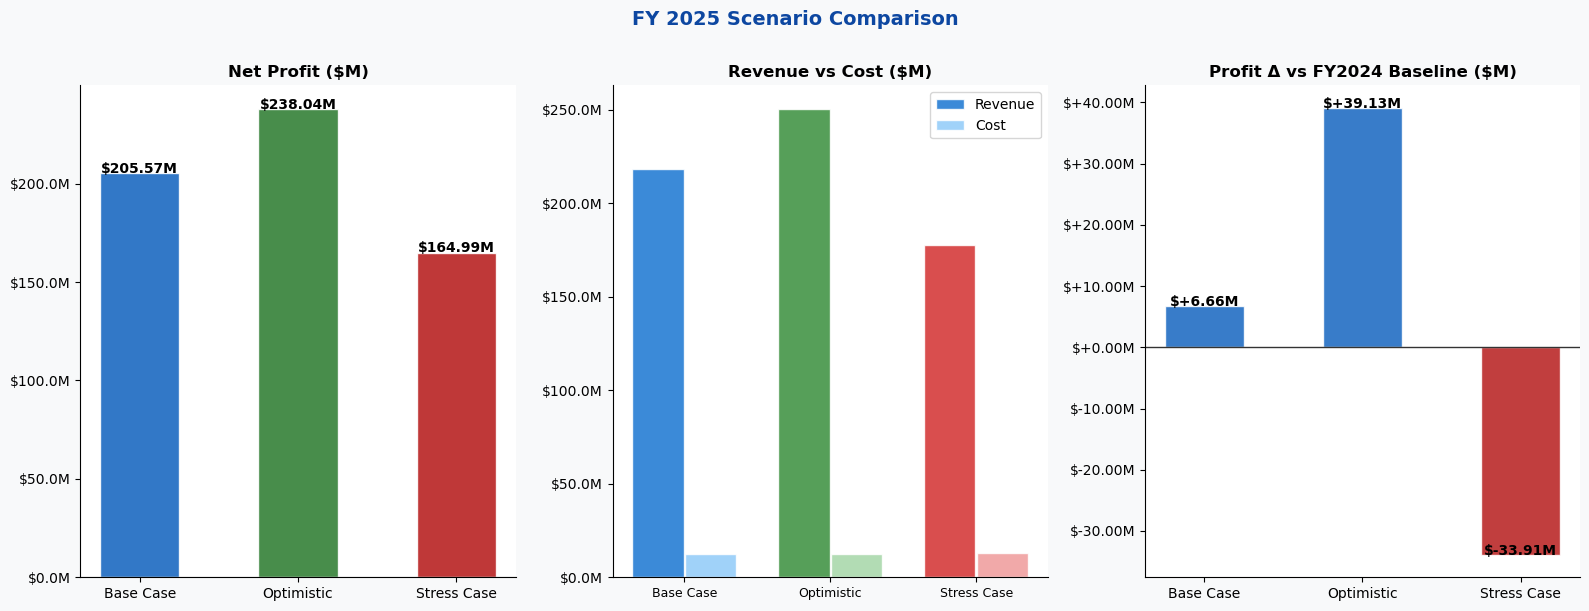

✅ scenario_comparison.png saved


In [11]:
names  = list(scenario_results.keys())
colors = ["#1565C0", "#2E7D32", "#B71C1C"]

profits_m  = [scenario_results[n]["profit"]  / 1e6 for n in names]
revenues_m = [scenario_results[n]["revenue"] / 1e6 for n in names]
costs_m    = [scenario_results[n]["cost"]    / 1e6 for n in names]

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 6))
fig2.patch.set_facecolor("#F8F9FA")
fig2.suptitle("FY 2025 Scenario Comparison", fontsize=14,
              fontweight="bold", y=1.01, color="#0D47A1")

# Net Profit per scenario
ax = axes2[0]
bars = ax.bar(names, profits_m, color=colors, alpha=0.88,
              edgecolor="white", width=0.5)
ax.set_title("Net Profit ($M)", fontweight="bold")
ax.axhline(0, color="#999", linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
for bar, val in zip(bars, profits_m):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + (0.05 if val >= 0 else -0.15),
            f"${val:.2f}M", ha="center", fontsize=10, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

# Revenue vs Cost grouped bar
ax = axes2[1]
x = np.arange(len(names))
ax.bar(x-0.18, revenues_m, 0.35, label="Revenue",
       color=["#1976D2","#388E3C","#D32F2F"], alpha=0.85, edgecolor="white")
ax.bar(x+0.18, costs_m,    0.35, label="Cost",
       color=["#90CAF9","#A5D6A7","#EF9A9A"], alpha=0.85, edgecolor="white")
ax.set_title("Revenue vs Cost ($M)", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.1f}M"))
ax.legend(); ax.spines[["top","right"]].set_visible(False)

# Profit delta vs FY2024 baseline
base_profit_m = (base_rev - base_cost) / 1e6
deltas        = [p - base_profit_m for p in profits_m]
delta_colors  = ["#1565C0" if d >= 0 else "#B71C1C" for d in deltas]
ax = axes2[2]
bars3 = ax.bar(names, deltas, color=delta_colors,
               alpha=0.85, edgecolor="white", width=0.5)
ax.set_title("Profit Δ vs FY2024 Baseline ($M)", fontweight="bold")
ax.axhline(0, color="#333", linewidth=1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:+.2f}M"))
for bar, val in zip(bars3, deltas):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + (0.02 if val >= 0 else -0.08),
            f"${val:+.2f}M", ha="center", fontsize=10, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("scenario_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ scenario_comparison.png saved")